In [3]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

nav_path = project_root / "data" / "raw" / "02_nav_history.csv"

print(nav_path)

nav = pd.read_csv(nav_path)

nav.head()

C:\Users\Shruti Singhania\mutual_fund_project\data\raw\02_nav_history.csv


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


# 1

In [4]:
nav['date'] = pd.to_datetime(nav['date'], dayfirst=True, format='mixed')

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

In [5]:
nav.head()

,amfi_code,date,nav,daily_return
5771,100016,2022-01-02,512.1124,NaN
5791,100016,2022-01-03,503.1674,-0.017467
5814,100016,2022-01-04,531.2850,0.055881
5857,100016,2022-01-06,474.1732,-0.107497
5879,100016,2022-01-07,452.5840,-0.045530


In [6]:
var_cvar = []

for fund, temp in nav.groupby('amfi_code'):

    returns = temp['daily_return'].dropna()

    var_95 = returns.quantile(0.05)

    cvar_95 = returns[returns <= var_95].mean()

    var_cvar.append([fund, var_95, cvar_95])

var_cvar_df = pd.DataFrame(var_cvar, columns=['amfi_code', 'VaR_95', 'CVaR_95'])

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.069066,-0.106756
1,100025,-0.022702,-0.038578
2,100033,-0.078258,-0.159839
3,101206,-0.071333,-0.131061
4,101207,-0.090472,-0.154317


In [7]:
from IPython.display import FileLink

var_cvar_df.to_csv("var_cvar_df.csv", index=False)

FileLink("var_cvar_df.csv")

C:\Users\Shruti Singhania\var_cvar_df.csv

# 2

In [8]:
import numpy as np
import matplotlib.pyplot as plt

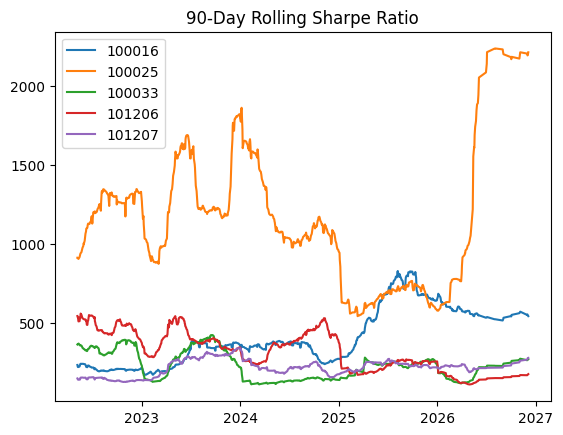

In [9]:
nav['sharpe'] = nav.groupby('amfi_code')['nav'].transform(lambda x: x.rolling(90).mean() / x.rolling(90).std() * np.sqrt(252))

# First 5 funds
funds = nav['amfi_code'].unique()[:5]

# Plot
for fund in funds:
    temp = nav[nav['amfi_code'] == fund]
    plt.plot(temp['date'], temp['sharpe'], label=fund)

plt.legend()
plt.title("90-Day Rolling Sharpe Ratio")
plt.show()

# 3

In [10]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

path = project_root / "data" / "raw" / "08_investor_transactions.csv"

print(path)

df = pd.read_csv(path)
df.shape

C:\Users\Shruti Singhania\mutual_fund_project\data\raw\08_investor_transactions.csv


(32778, 13)

In [11]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], dayfirst=True, format='mixed')

In [12]:
first_year = (df.groupby('investor_id')['transaction_date'].min().dt.year)

In [13]:
df['cohort_year'] = df['investor_id'].map(first_year)

In [14]:
avg_sip = (df[df['transaction_type'] == 'SIP'].groupby('cohort_year')['amount_inr'].mean())

In [15]:
total_invested = (df.groupby('cohort_year')['amount_inr'].sum())

In [16]:
top_fund = (df.groupby(['cohort_year','amfi_code']).size().reset_index(name='count'))
top_fund = (top_fund.sort_values(['cohort_year','count'], ascending=False).drop_duplicates('cohort_year'))
top_fund

,cohort_year,amfi_code,count
62,2025,119599,12
35,2024,148568,874


In [17]:
result = pd.DataFrame({'avg_sip_amount': avg_sip, 'total_invested': total_invested}).reset_index()

result = result.merge(top_fund[['cohort_year','amfi_code']],on='cohort_year')

print(result)

   cohort_year  avg_sip_amount  total_invested  amfi_code
0         2024    10996.885825      3491125187     148568
1         2025    13505.209581        30455243     119599


# 4

In [18]:
sip = df[df['transaction_type'] == 'SIP']

In [19]:
result = []
 
for investor, temp in sip.groupby('investor_id'):
    if len(temp) >= 6:
        temp = temp.sort_values('transaction_date')
        avg_gap = (temp['transaction_date'].diff().dt.days.mean())
        status = (
            'At Risk'
            if avg_gap > 35
            else 'Healthy'
        )
        result.append([investor, round(avg_gap,2), status])

In [20]:
sip_continuity = pd.DataFrame(result, columns=['investor_id', 'avg_gap_days', 'status'])

print(sip_continuity.head())
sip_continuity.shape

  investor_id  avg_gap_days   status
0   INV000004         85.40  At Risk
1   INV000008         70.40  At Risk
2   INV000010         64.80  At Risk
3   INV000011         40.17  At Risk
4   INV000012         57.00  At Risk


(1362, 3)

# 5 

In [21]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

funds_path = project_root / "data" / "processed" / "clean_performance.xls"

print(funds_path)

funds = pd.read_csv(funds_path)
funds.shape

C:\Users\Shruti Singhania\mutual_fund_project\data\processed\clean_performance.xls


(40, 20)

In [22]:
funds.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,negative_sharpe_flag
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False


In [23]:
risk = input("Enter Risk Appetite (Low/Moderate/High): ").strip().lower()

if risk == "low": temp = funds[funds['risk_grade'].str.lower() == 'low']

elif risk == "moderate": temp = funds[funds['risk_grade'].str.lower().isin(['moderate','moderately high'])]

elif risk == "high": temp = funds[funds['risk_grade'].str.lower().isin(['high','very high'])]

recommendation = temp.sort_values('sharpe_ratio',ascending=False).head(3)

print(recommendation[['amfi_code','scheme_name','risk_grade','sharpe_ratio']])

Enter Risk Appetite (Low/Moderate/High):  low


    amfi_code                               scheme_name risk_grade  \
14     120507  ICICI Pru Liquid Fund - Regular - Growth        Low   
23     120844      Kotak Liquid Fund - Regular - Growth        Low   
30     101208       ABSL Liquid Fund - Regular - Growth        Low   

    sharpe_ratio  
14          7.68  
23          6.18  
30          5.14  


# 6

In [24]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

hold_path = project_root / "data" / "raw" / "09_portfolio_holdings.csv"

print(hold_path)

portfolio = pd.read_csv(hold_path)

sector_weights = (portfolio.groupby(['amfi_code', 'sector'])['weight_pct'].sum().reset_index())

sector_weights.head()

C:\Users\Shruti Singhania\mutual_fund_project\data\raw\09_portfolio_holdings.csv


,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [25]:
sector_weights['weight'] = sector_weights['weight_pct'] / 100

hhi = (sector_weights.groupby('amfi_code')['weight'].apply(lambda x: (x**2).sum()).reset_index(name='HHI'))

print(hhi.head())

   amfi_code       HHI
0     100016  0.180588
1     100033  0.227647
2     101206  0.180042
3     101207  0.222727
4     102885  0.180712


In [26]:
hhi = hhi.sort_values('HHI', ascending=False)

print(hhi)

    amfi_code       HHI
11     119092  0.296769
30     148569  0.254992
27     125498  0.253155
6      102887  0.251383
32     149323  0.241077
21     120505  0.238695
10     118635  0.237497
18     119599  0.232361
22     120506  0.231464
1      100033  0.227647
16     119552  0.227508
3      101207  0.222727
20     120504  0.221213
8      118633  0.221200
29     148568  0.218086
23     120841  0.215893
7      118632  0.207259
28     148567  0.201248
33     149324  0.188701
17     119598  0.188085
12     119093  0.184233
31     149322  0.182695
19     120503  0.182167
4      102885  0.180712
0      100016  0.180588
2      101206  0.180042
13     119094  0.175100
26     125497  0.172411
24     120842  0.162062
9      118634  0.160299
14     119095  0.159582
15     119551  0.142491
25     120843  0.136206
5      102886  0.124020


In [27]:
def concentration(h):
    if h > 0.25:
        return "Highly Concentrated"
    elif h > 0.15:
        return "Moderately Concentrated"
    else:
        return "Well Diversified"

hhi['portfolio_type'] = hhi['HHI'].apply(concentration)

hhi.head()

,amfi_code,HHI,portfolio_type
11,119092,0.296769,Highly Concentrated
30,148569,0.254992,Highly Concentrated
27,125498,0.253155,Highly Concentrated
6,102887,0.251383,Highly Concentrated
32,149323,0.241077,Moderately Concentrated


In [28]:
from IPython.display import FileLink

hhi.to_csv("sector_hhi.csv", index=False)

FileLink("sector_hhi.csv")

C:\Users\Shruti Singhania\sector_hhi.csv

# 7

## Advanced Insights

### 1. Risk Analysis
Fund 100016 exhibited the highest 95% VaR and CVaR among all schemes, indicating the highest downside risk during adverse market conditions.

### 2. Risk-Adjusted Performance
Fund 100025 consistently maintained the highest 90-day rolling Sharpe Ratio, suggesting superior risk-adjusted returns compared to peers.

### 3. Investor Cohort Behaviour
Investors who started investing in 148568 contributed the highest total investment amount, indicating strong participation from that cohort.

### 4. SIP Continuity
Approximately 4.155% were flagged as At-Risk due to average gaps exceeding 35 days.

### 5. Portfolio Concentration
Fund 119092 recorded the highest Sector HHI score, indicating a concentrated sector exposure, whereas Fund 102886 was the most diversified across sectors.